# Solving the transient Richards equation
The goal is to solve the transient mixed Richards equation. <br>

$\frac{\partial \theta}{\partial t} - \nabla\cdot(k\nabla(z+h)) = 0$ <br>

which means that the hydraulic pressure head is negative above the saturation zone. <br>
Here the parametrizations are simplified to: <br>
$k=k_sk_r$ with $k_r = e^{\alpha h}$ (Gardner),<br> 
$k_r = (\frac{\theta - \theta_r}{\theta_s - \theta_r})^m$ (Irmay) <br>
where $\alpha, m$ are parameters. For even further simplification we choose $m=1$ here. (I.e. $\theta = \theta_r + (\theta_s-\theta_r)e^{\alpha h}$)<br>
We choose $\Omega = [0, a=15.24]\times[0, L=15.24]$, $\alpha=0.19$ and $h_r = -15.24$. <br>

Boundary conditions: <br>
- $h=h_r$ on $x=0,~x=a,~z=0$
- $h = \frac{1}{\alpha}\ln(e^{\alpha h_r}+\bar h_0\sin(\frac{\pi x}{a}))$ with $\bar h_0 = 1-e^{\alpha h_r}$ on $z=L$

Initial condition: $h=h_r$ at $t=0$ everywhere.

In [1]:
import numpy as np
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    functionspace,
    dirichletbc,
    locate_dofs_geometrical,
    form,
    extract_function_spaces,
)
from dolfinx.fem.petsc import (
    LinearProblem, 
    NonlinearProblem, 
    create_matrix, 
    create_vector, 
    assemble_matrix, 
    assemble_vector,
    apply_lifting,
    set_bc,
    )
from dolfinx.mesh import create_unit_square, locate_entities, meshtags, create_rectangle, CellType
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
from ufl import (
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    dx,
    grad,
    div,
    inner,
    exp,
    lhs,
    rhs,
    derivative,
    conditional,
    sqrt,
    ln,
)

from petsc4py import PETSc
from visualization_fct import *


In [37]:
# Define time discretization parameters
t = 0.0 # start time
T = 5*24*60*60 # end time
delta_t = 172.8 # time step size
num_steps = int(np.floor(T/delta_t))
print(num_steps)

# Define constants
alpha = 0.19 # Gardner exponent
theta_r = 0.15 # residual water content
theta_s = 0.45 # saturated water content
L = a = 15.24 # height, length of box
h_r = -15.24 # pressure head when the soil is very dry
Ks = 3e-6 # saturated hydraulic conductivity

# Solution constants
h_0 = 1 - np.exp(alpha*h_r)
beta = np.sqrt(alpha**2/4 + (np.pi/a)**2)
beta_1 = np.sqrt(alpha**2/4 + (np.pi*2/a)**2)

2500


In [38]:
# Create mesh
domain = create_rectangle(MPI.COMM_WORLD, ((0,0), (a, L)), (100,100), cell_type=CellType.quadrilateral)
V = functionspace(domain, ("CG", 1)) # linear Lagrange
x = SpatialCoordinate(domain)


def kr(u):
    return exp(alpha*u)

def C(u):
    # C(h)=dtheta/dh
    return alpha*(theta_s - theta_r)*kr(u)

def theta(u):
    return theta_r + (theta_s - theta_r)*kr(u)

In [39]:
# Define Dirichlet boundary conditions

def left_or_right(x):
    return np.logical_or(np.isclose(x[0], 0), np.isclose(x[0], a))

dofs_fix = locate_dofs_geometrical(
    V, lambda x: np.logical_or(left_or_right(x), np.isclose(x[1], 0)))
bc_fix = dirichletbc(Constant(domain, default_scalar_type(h_r)), dofs_fix, V)

dofs_no = locate_dofs_geometrical(V, lambda x: np.isclose(x[1], 0))
bc_no = dirichletbc(Constant(domain, default_scalar_type(h_r)), dofs_no, V)

def expr_h_fix(x):
    return 1/alpha*np.log(np.exp(alpha*h_r) + h_0*np.sin(np.pi*x[0]/a))

def expr_h_noflow(x):
    return 1/alpha*np.log(np.exp(alpha*h_r) + h_0/2*(1-np.cos(2*np.pi*x[0]/a)))


dofs_L = locate_dofs_geometrical(V, lambda x: np.isclose(x[1], L))

h_top_fix = Function(V)
h_top_fix.interpolate(expr_h_fix)
bc_top_fix = dirichletbc(h_top_fix, dofs_L)

h_top_no = Function(V)
h_top_no.interpolate(expr_h_noflow)
bc_top_no = dirichletbc(h_top_no, dofs_L)

## Modified Picard Iteration

In [10]:
v = TestFunction(V)

u_n = Function(V)
u_n.x.array[:] = h_r # previous (time step) solution

max_iter = 10 # maximum number of Picard iterations
tol = 1e-6

for n in range(num_steps):
    u_m = Function(V)
    u_m.x.array[:] = u_n.x.array # First guess for Picard: previous time step
    du = TrialFunction(V)
    
    # Build variational formulation
    C_part = 1/delta_t * C(u_m) * du * v * dx
    var_part = inner(Ks * kr(u_m) * grad(du), grad(v)) * dx
    rest = inner(Ks * kr(u_m) * grad(u_m + x[1]), grad(v)) * dx + (theta(u_m) - theta(u_n)) / delta_t  * v * dx
    F = C_part + var_part + rest
    a_fem = lhs(F)
    L_fem = rhs(F)

    #du = Function(V)
    u_mp1 = Function(V)

    # Prepare Picard iteration
    m = 0 # iteration count
    eps = 1

    while eps > tol and m < max_iter:
        # Calculate boundary conditions for du: du@bd = u_D - u_m@bd
        du_top_fix = Function(V)
        du_top_fix.interpolate(expr_h_fix)
        du_top_fix.x.array[:] = du_top_fix.x.array - u_m.x.array
        bc_du_top = dirichletbc(du_top_fix, dofs_L)

        du_rest = Function(V)
        du_rest.x.array[:] = h_r - u_m.x.array
        bc_du = dirichletbc(du_rest, dofs_fix)

        problem = LinearProblem(
            a_fem, L_fem, bcs=[bc_du, bc_du_top],
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix="Picard_"
            )
        du = problem.solve()
        u_mp1.x.array[:] = u_m.x.array + du.x.array
        eps = np.linalg.norm(du.x.array, ord=np.inf)
        print(f"Time step {n}, iteration {m}, Error ||u_n^m-u_n^(m+1)|| {eps:.3e}")
        u_m.x.array[:] = u_mp1.x.array
        m += 1

    u_n.x.array[:] = u_mp1.x.array

Time step 0, iteration 0, Error ||u_n^m-u_n^(m+1)|| 1.524e+01
Time step 0, iteration 1, Error ||u_n^m-u_n^(m+1)|| 1.790e-01
Time step 0, iteration 2, Error ||u_n^m-u_n^(m+1)|| 2.475e-02
Time step 0, iteration 3, Error ||u_n^m-u_n^(m+1)|| 4.387e-03
Time step 0, iteration 4, Error ||u_n^m-u_n^(m+1)|| 7.815e-04
Time step 0, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.394e-04
Time step 0, iteration 6, Error ||u_n^m-u_n^(m+1)|| 2.486e-05
Time step 0, iteration 7, Error ||u_n^m-u_n^(m+1)|| 4.435e-06
Time step 0, iteration 8, Error ||u_n^m-u_n^(m+1)|| 7.911e-07
Time step 1, iteration 0, Error ||u_n^m-u_n^(m+1)|| 3.564e+00
Time step 1, iteration 1, Error ||u_n^m-u_n^(m+1)|| 7.318e-02
Time step 1, iteration 2, Error ||u_n^m-u_n^(m+1)|| 9.268e-03
Time step 1, iteration 3, Error ||u_n^m-u_n^(m+1)|| 1.175e-03
Time step 1, iteration 4, Error ||u_n^m-u_n^(m+1)|| 1.490e-04
Time step 1, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.889e-05
Time step 1, iteration 6, Error ||u_n^m-u_n^(m+1)|| 2.396e-06
Time ste

2026-04-02 13:37:17.787 (  36.396s) [    7F53C599F600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


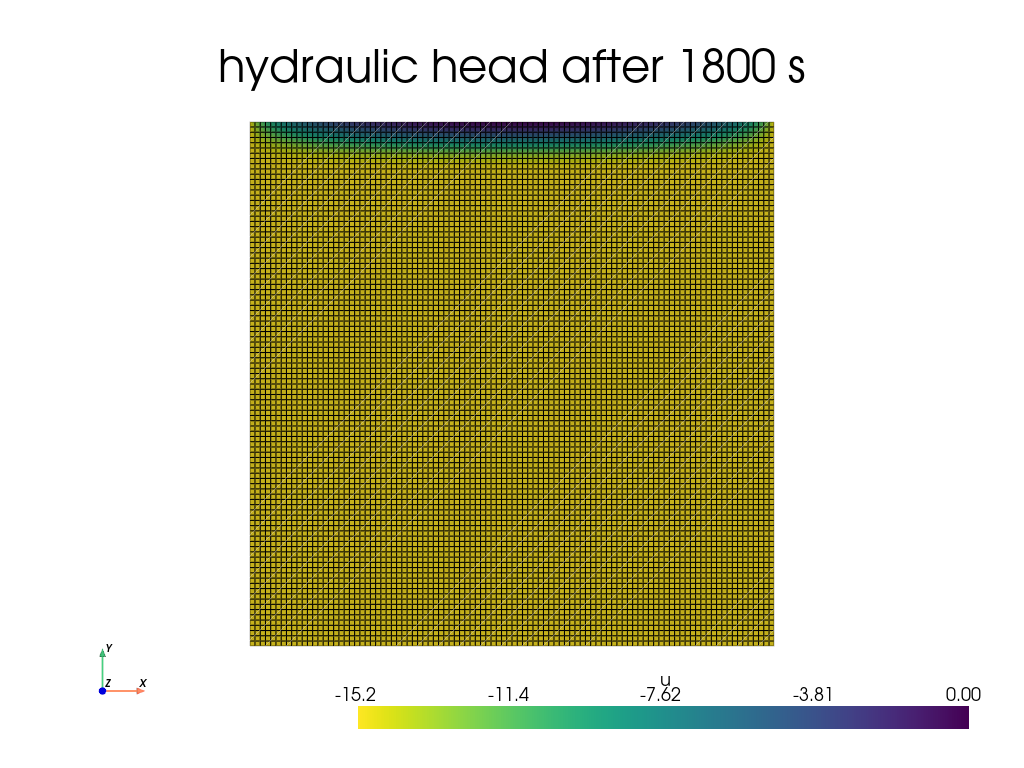

In [11]:
plotScalarFunction(V,u_n, title=f"hydraulic head after {T} s", cmap = "viridis_r")

#### Try without "trick"

In [12]:
v = TestFunction(V)
u_n = Function(V)
u_n.x.array[:] = h_r # previous (time step) solution

max_iter = 10 # maximum number of Picard iterations
tol = 1e-6

for n in range(num_steps):
    u_m = Function(V)
    u_m.x.array[:] = u_n.x.array

    u_mp1 = TrialFunction(V)

    F = C(u_m) / delta_t * (u_mp1 - u_n) * v * dx 
    F += inner(Ks * kr(u_m) * grad(x[1] + u_mp1), grad(v)) * dx
    a_fem = lhs(F)
    L_fem = rhs(F)

    eps = 1
    m = 0
    while eps > tol and m < max_iter:
        problem = LinearProblem(
            a_fem, L_fem, bcs=[bc_top_fix, bc_fix],
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix="Picard_",
            )
        u_mp1 = problem.solve()

        diff = u_mp1.x.array - u_m.x.array
        eps = np.linalg.norm(diff, ord=np.inf)
        print(f"Time step {n}, iteration {m}, Error ||u_n^m-u_n^(m+1)|| {eps:.3e}")

        u_m.x.array[:] = u_mp1.x.array
        m += 1
    
    u_n.x.array[:] = u_mp1.x.array

    


        

Time step 0, iteration 0, Error ||u_n^m-u_n^(m+1)|| 1.524e+01
Time step 0, iteration 1, Error ||u_n^m-u_n^(m+1)|| 4.695e+00
Time step 0, iteration 2, Error ||u_n^m-u_n^(m+1)|| 9.957e-01
Time step 0, iteration 3, Error ||u_n^m-u_n^(m+1)|| 2.279e-01
Time step 0, iteration 4, Error ||u_n^m-u_n^(m+1)|| 4.877e-02
Time step 0, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.053e-02
Time step 0, iteration 6, Error ||u_n^m-u_n^(m+1)|| 2.261e-03
Time step 0, iteration 7, Error ||u_n^m-u_n^(m+1)|| 4.861e-04
Time step 0, iteration 8, Error ||u_n^m-u_n^(m+1)|| 1.045e-04
Time step 0, iteration 9, Error ||u_n^m-u_n^(m+1)|| 2.246e-05
Time step 1, iteration 0, Error ||u_n^m-u_n^(m+1)|| 6.744e+00
Time step 1, iteration 1, Error ||u_n^m-u_n^(m+1)|| 1.879e+00
Time step 1, iteration 2, Error ||u_n^m-u_n^(m+1)|| 5.069e-01
Time step 1, iteration 3, Error ||u_n^m-u_n^(m+1)|| 1.401e-01
Time step 1, iteration 4, Error ||u_n^m-u_n^(m+1)|| 3.846e-02
Time step 1, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.058e-02


Time step 1, iteration 6, Error ||u_n^m-u_n^(m+1)|| 2.908e-03
Time step 1, iteration 7, Error ||u_n^m-u_n^(m+1)|| 7.996e-04
Time step 1, iteration 8, Error ||u_n^m-u_n^(m+1)|| 2.198e-04
Time step 1, iteration 9, Error ||u_n^m-u_n^(m+1)|| 6.043e-05
Time step 2, iteration 0, Error ||u_n^m-u_n^(m+1)|| 3.951e+00
Time step 2, iteration 1, Error ||u_n^m-u_n^(m+1)|| 7.450e-01
Time step 2, iteration 2, Error ||u_n^m-u_n^(m+1)|| 1.384e-01
Time step 2, iteration 3, Error ||u_n^m-u_n^(m+1)|| 2.592e-02
Time step 2, iteration 4, Error ||u_n^m-u_n^(m+1)|| 4.846e-03
Time step 2, iteration 5, Error ||u_n^m-u_n^(m+1)|| 9.063e-04
Time step 2, iteration 6, Error ||u_n^m-u_n^(m+1)|| 1.695e-04
Time step 2, iteration 7, Error ||u_n^m-u_n^(m+1)|| 3.170e-05
Time step 2, iteration 8, Error ||u_n^m-u_n^(m+1)|| 5.927e-06
Time step 2, iteration 9, Error ||u_n^m-u_n^(m+1)|| 1.108e-06
Time step 3, iteration 0, Error ||u_n^m-u_n^(m+1)|| 2.619e+00
Time step 3, iteration 1, Error ||u_n^m-u_n^(m+1)|| 3.615e-01
Time ste

## Newton method

In [40]:
v = TestFunction(V)
uh = Function(V)
u_N = Function(V)
u_N.x.array[:] = h_r # initial value
x = SpatialCoordinate(domain)
bc = [bc_fix, bc_top_fix]

F = C(uh) / delta_t * (uh - u_N) * v * dx
F += inner(Ks * kr(uh) * grad(x[1] + uh), grad(v)) * dx

J = derivative(F, uh)

petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "snes_monitor_cancel": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "ksp_monitor_cancel": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

for n in range(num_steps):
    problem = NonlinearProblem(
        F,
        uh,
        bcs=bc,
        J=J,
        petsc_options=petsc_options,
        petsc_options_prefix="SNES_",
    )

    uh = problem.solve()
    converged = problem.solver.getConvergedReason()
    num_iter = problem.solver.getIterationNumber()
    assert converged > 0, f"Solver did not converge, got {converged}."
    """ print(
        f"Solver converged at timestep {n} after {num_iter} iterations with converged reason {converged}."
    ) """

    u_N.x.array[:] = uh.x.array

In [41]:
np.save("Richards_after_5_days",uh.x.array)

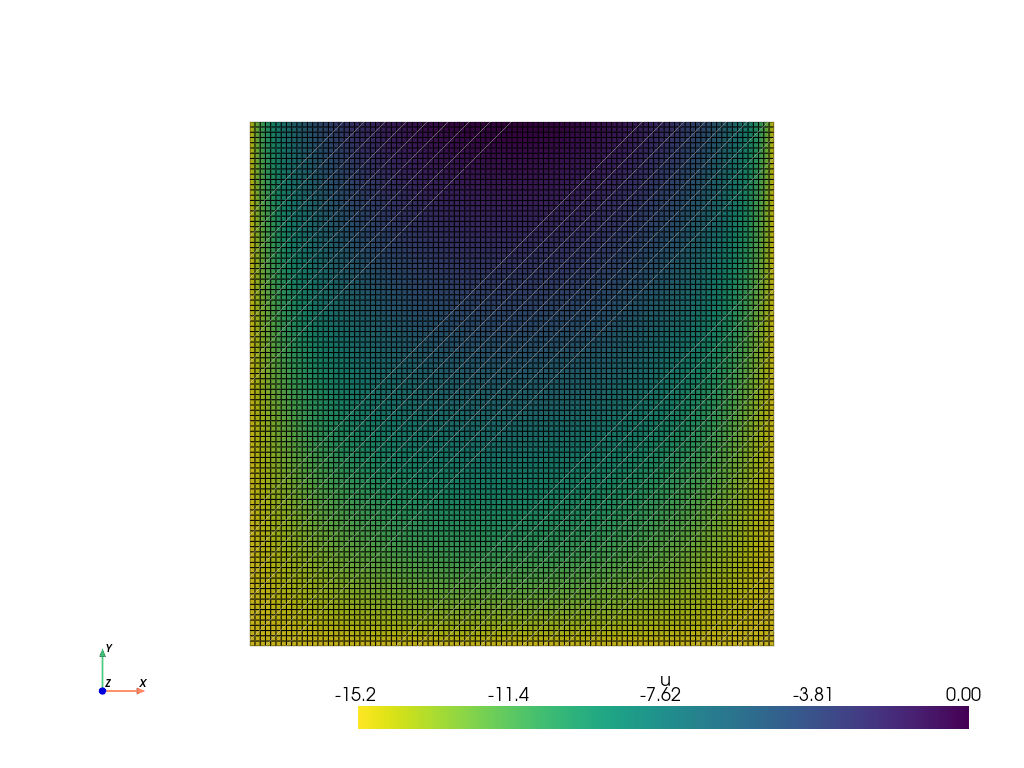

In [42]:
plotScalarFunction(V, uh, cmap="viridis_r")

## Analyse solution

In [32]:
# Grids
x_grid = np.linspace(0, a, 100)
z_grid = np.linspace(0, L, 100)
X, Z = np.meshgrid(x_grid, z_grid)

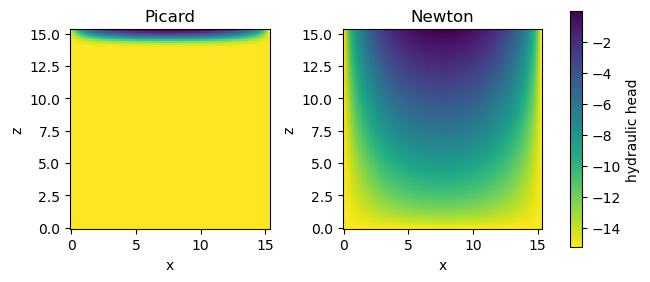

In [ ]:

def eval_try(x, z, u):
    h = np.zeros((len(z), len(x)))
    for i, z_cor in enumerate(z):
        p = np.vstack([x, np.full(len(x), z_cor), np.zeros(len(x))])
        pts, values = evaluate_fct(domain, p, u)
        h[i, :] = np.array(values).flatten()
    return h

heads_Picard = eval_try(x_grid, z_grid, [u_n])
heads_Newton = eval_try(x_grid, z_grid, [uh])

fig, ax = plt.subplots(1, 2, layout="constrained")
con1 = ax[0].pcolormesh(X, Z, heads_Picard, cmap="viridis_r")
ax[0].set_aspect("equal", "box")
ax[0].set_xlabel("x")
ax[0].set_ylabel("z")
ax[0].set_title("Picard")

con2 = ax[1].pcolormesh(X, Z, heads_Newton, cmap="viridis_r")
ax[1].set_aspect("equal", "box")
ax[1].set_xlabel("x")
ax[1].set_ylabel("z")
ax[1].set_title("Newton")

cbar = fig.colorbar(con2, ax=ax.ravel().tolist(), shrink=0.5)
cbar.set_label("hydraulic head")


In [43]:
def exact_specified_head(x, z_cor):
    bar_h = h_0 * np.sin(np.pi*x/a) * np.exp(alpha/2*(L-z_cor)) * np.sinh(beta*z_cor) / np.sinh(beta*L)
    h = 1/alpha * np.log(np.exp(alpha*h_r) + bar_h)
    return h
# Evaluate solutions on grid
def eval_head(x, z, fct):
    head = np.zeros((len(x), len(x)))
    for i, z_cor in enumerate(z):
        head[i, :] = fct(x, z_cor)
    return head

def eval_try(x, z, u):
    h = np.zeros((len(z), len(x)))
    for i, z_cor in enumerate(z):
        p = np.vstack([x, np.full(len(x), z_cor), np.zeros(len(x))])
        pts, values = evaluate_fct(domain, p, u)
        h[i, :] = np.array(values).flatten()
    return h

h_fix = eval_head(x_grid, z_grid, exact_specified_head)
heads_Newton = eval_try(x_grid, z_grid, [uh])

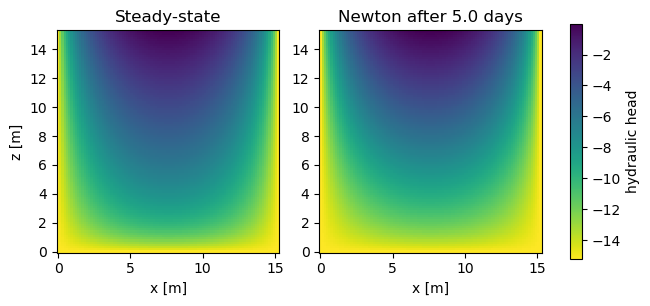

In [44]:
vmin = np.min([h_fix, heads_Newton])
vmax = np.max([h_fix, heads_Newton])

fig, ax = plt.subplots(1, 2, layout="constrained")
con1 = ax[0].pcolormesh(X, Z, h_fix, cmap="viridis_r", vmin=vmin, vmax=vmax)
ax[0].set_aspect("equal", "box")
ax[0].set_xlabel("x [m]")
ax[0].set_ylabel("z [m]")
ax[0].set_title("Steady-state")

con2 = ax[1].pcolormesh(X, Z, heads_Newton, cmap="viridis_r", vmin=vmin, vmax=vmax)
ax[1].set_aspect("equal", "box")
ax[1].set_xlabel("x [m]")
ax[1].set_title(f"Newton after {T/(24*60*60)} days")

cbar = fig.colorbar(con2, ax=ax.ravel().tolist(), shrink=0.5)
cbar.set_label("hydraulic head")


<a list of 15 text.Text objects>

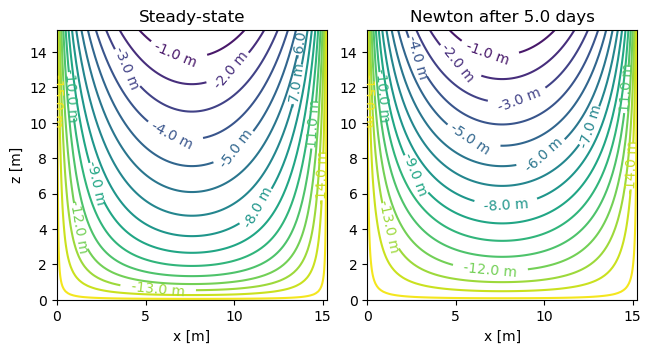

In [45]:
vmin = np.min([h_fix, heads_Newton])
vmax = np.max([h_fix, heads_Newton])

fig, ax = plt.subplots(1, 2, layout="constrained")
con1 = ax[0].contour(X, Z, h_fix, cmap="viridis_r", levels=15, vmin=vmin, vmax=vmax)
ax[0].set_aspect("equal", "box")
ax[0].set_xlabel("x [m]")
ax[0].set_ylabel("z [m]")
ax[0].set_title("Steady-state")
ax[0].clabel(con1, fmt="%1.1f m")

con2 = ax[1].contour(X, Z, heads_Newton, cmap="viridis_r", levels=15, vmin=vmin, vmax=vmax)
ax[1].set_aspect("equal", "box")
ax[1].set_xlabel("x [m]")
ax[1].set_title(f"Newton after {T/(24*60*60)} days")
ax[1].clabel(con2, fmt="%1.1f m")


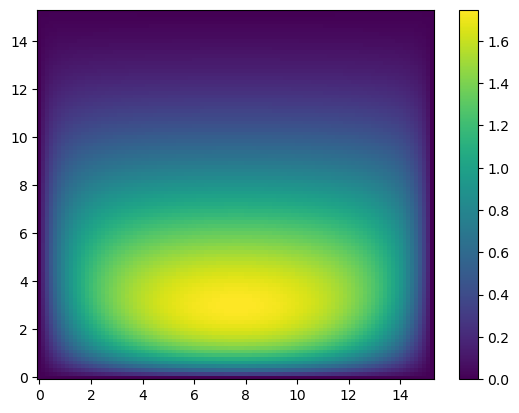

In [46]:
plt.pcolormesh(X,Z, h_fix - heads_Newton)
plt.colorbar()

Text(0.5, 1.0, 'wetting front after 432000 s at x = 8 m')

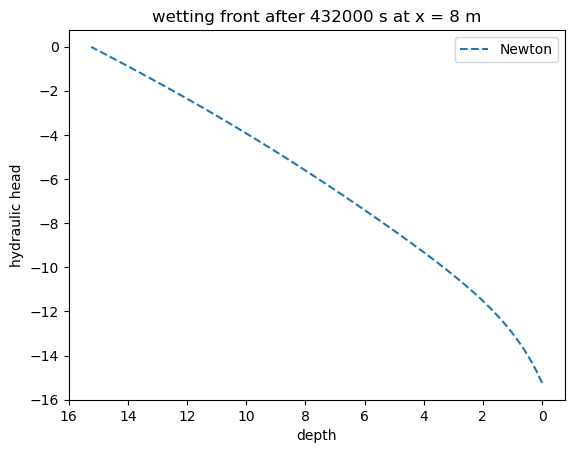

In [16]:
#wetting_front_P = eval_try([8], z_grid, [u_n])
wetting_front_N = eval_try([8], z_grid, [uh])
fig, ax = plt.subplots(1,1)
#ax.plot(z_grid, wetting_front_P, '--', label="Picard")
ax.plot(z_grid, wetting_front_N, '--', label="Newton")
ax.set_ylabel("hydraulic head")
ax.set_xlabel("depth")
ax.invert_xaxis()
ax.legend()
ax.set_title(f"wetting front after {T} s at x = 8 m")